# Exploratory data analysis: CBIS-DDSM mass cases

This notebook describes the data before any model is trained: what the mass cases of CBIS-DDSM [1], [2] contain, how they are partitioned, what the files look like on disk, and what that implies for preprocessing. It covers the first three steps of Chollet's workflow [3]: define the problem and assemble the data, choose a measure of success, and decide the evaluation protocol.

**Scope.** Mass cases only; calcification cases are outside the project. The unit in this notebook is the mammogram image. The classifiers and the localiser work on individual lesions, and that view of the data is in `02_lesion_geometry`.

**Use of the test partition.** The test partition appears here only through its recorded counts and ratios of them, plus its patient identifiers for the disjointness check in section 4. The loader's own log lines in section 1 describe each case file as a whole. Sections 2.2, 2.3, 3, 11, 12.1, 12.2 and 12.3 cover all partitions: they read the case files, paths and headers of every file, because preprocessing has to be safe for all of them, and they use no labels. In section 12.2 this is only the median height, which splits the labelled training and validation images. Every other distribution, statistic and image shown comes from the training and validation partitions.

**Numbers.** Any figure that depends on the partition is printed by a code cell and is not repeated in the text, so the text cannot disagree with the data.

| section | purpose |
| :--- | :--- |
| 0. Setup | seeds, paths, imports |
| 1. Loading and partition | pool the two official CSV files, label, split by patient |
| 2. Data integrity | missing values, duplicate image paths, images with more than one lesion |
| 3. ROI masks and crops | files present; which file is the mask; one mask per lesion |
| 4. Patient-level split | disjointness of the three partitions; size and balance of each |
| 5. Class distribution and prevalence | label balance; this dataset against the assessment clinic and the screening population |
| 6. Clinical descriptors | mass shape, margins, assessment and subtlety against the label |
| 7. Breast density | distribution, and association with the label |
| 8. The BI-RADS assessment | why assessment 0 is off the scale; disagreement between assessment and pathology |
| 9. View coverage | availability of CC and MLO views per breast |
| 10. Sample images | visual check of decoding and labels |
| 11. DICOM header audit | bit depth and photometric interpretation of every mammogram |
| 12. Image resolution | size distribution; scanner type against the label; mask and mammogram on one grid |
| 13. Pixel intensity and normalisation | intensity distribution; training-set statistics; shift between partitions |
| 14. Summary | what the data looks like and what preprocessing must do |

**References**

[1] R. S. Lee, F. Gimenez, A. Hoogi, K. K. Miyake, M. Gorovoy and D. L. Rubin, "A curated mammography data set for use in computer-aided detection and diagnosis research," *Scientific Data*, vol. 4, 170177, 2017. doi: 10.1038/sdata.2017.177

[2] R. Sawyer-Lee, F. Gimenez, A. Hoogi and D. Rubin, "Curated Breast Imaging Subset of Digital Database for Screening Mammography (CBIS-DDSM) [Data set]," The Cancer Imaging Archive, 2016. doi: 10.7937/K9/TCIA.2016.7O02S9CY. Accessed: 5 May 2026.

[3] F. Chollet, *Deep Learning with Python*. Shelter Island, NY: Manning, 2018.

[4] University of South Florida, "Digital Database for Screening Mammography: Overview of Volume benign_without_callback_01." [Online]. Available: http://www.eng.usf.edu/cvprg/mammography/DDSM/thumbnails/benign_without_callbacks/benign_without_callback_01/overview.html. Archived: https://web.archive.org/web/20200807032156/http://www.eng.usf.edu/cvprg/mammography/DDSM/thumbnails/benign_without_callbacks/benign_without_callback_01/overview.html. Accessed: 23 Sep. 2026.

[5] M. Heath, K. Bowyer, D. Kopans, R. Moore and W. P. Kegelmeyer Jr., "The Digital Database for Screening Mammography," in Proc. 5th Int. Workshop on Digital Mammography, 2001, pp. 212–218.

[6] NHS England, "Breast Screening Programme, England, 2024-25," 19 Feb. 2026. [Online]. Available: https://digital.nhs.uk/data-and-information/publications/statistical/breast-screening-programme/england-2024-2025. Accessed: 21 Sep. 2026.

[7] C. J. D'Orsi, E. A. Sickles, E. B. Mendelson and E. A. Morris et al., *ACR BI-RADS Atlas: Breast Imaging Reporting and Data System*, 5th ed. Reston, VA: American College of Radiology, 2013.

[8] L. Wang, "Mammography with deep learning for breast cancer detection," *Frontiers in Oncology*, vol. 14, 1281922, 2024. doi: 10.3389/fonc.2024.1281922



## 0. Setup

Seeds, paths and constants come from `src/config.py`. Nothing is set by hand in this notebook.

In [1]:
import json
import os
import random
import sys
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.metrics import roc_auc_score

from src import config
from src import data_loader as dl

SEED = config.SEED
random.seed(SEED)
np.random.seed(SEED)

CONFIG = {
    "train_csv": config.TRAIN_CSV,
    "test_csv": config.TEST_CSV,
    "train_img_dir": config.TRAIN_IMG_DIR,
    "test_img_dir": config.TEST_IMG_DIR,
    "figures_dir": config.FIGURES_DIR / "eda",
    "img_col": "image file path",
    "clinical_cols": ["mass shape", "mass margins", "assessment", "subtlety"],
    "valid_views": ["CC", "MLO"],
    "target_size": config.TARGET_SIZE,
}

for key in ("train_csv", "test_csv", "train_img_dir", "test_img_dir"):
    assert CONFIG[key].exists(), f"Path not found: CONFIG['{key}']"

CONFIG["figures_dir"].mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "figure.figsize": (10, 6),
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "savefig.bbox": "tight",
        "savefig.dpi": 150,
    }
)


def show(df: pd.DataFrame, formats: dict[str, str]) -> None:
    """Display a table with the given columns formatted as text."""
    display(df.assign(**{col: df[col].map(fmt.format) for col, fmt in formats.items()}))


print(f"numpy {np.__version__} | pandas {pd.__version__} | pydicom {pydicom.__version__}")

numpy 1.26.4 | pandas 3.0.2 | pydicom 3.0.2


## 1. Loading and partition

**The problem** (step 1 of the workflow [3]).

- **Input:** one mammogram, a single view of one breast, stored as a DICOM file.
- **Output:** a binary label, malignant (1) or benign (0). The dataset's `BENIGN_WITHOUT_CALLBACK` category counts as benign.
- **One row per image.** The case files hold one row per abnormality, and a mammogram can show more than one mass. The loader reduces them to one row per image: the label and the BI-RADS assessment take the maximum over the image's masses, so malignant wins, and subtlety takes the minimum, the least conspicuous mass. The loader prints how many rows it merges.
- **The patient is the unit of independence.** A patient contributes several images, and images of one patient share tissue, density and scanner. A split by image would let the model be tested on patients it has trained on.

**The partition.** The dataset is released as a training and a test file with no validation set. This project needs three partitions, because no test result is the criterion for any selection: choices are made on validation data, and test results are reported from the final evaluation. The two files are therefore pooled and split once by patient, stratified on the label, into about 70 / 15 / 15 per cent (`StratifiedGroupKFold`, seed from `config`). Patients are assigned once, on the pooled lesions, and every view of the data follows that assignment. Because the split is made here and not inherited, its disjointness is checked directly in section 4.

**The test partition is not loaded.** `split_frames` refuses it outside the final evaluation. Its size is read from `outputs/results/data_flow.json`, the record the pipeline wrote when it ran.

The cell also checks the training and validation frames against that record, so this notebook cannot describe a different split from the one the models used.

In [2]:
raw_train = pd.read_csv(CONFIG["train_csv"])
raw_test = pd.read_csv(CONFIG["test_csv"])
print(f"Case files: {len(raw_train):,} + {len(raw_test):,} abnormality rows\n")

frames = dl.split_frames("full")
train_df, val_df = frames["train"], frames["val"]
PARTITIONS = {"Train": train_df, "Val": val_df}

with open(config.RESULTS_DIR / "data_flow.json") as f:
    recorded = json.load(f)["partitions"]

for name, df in (("train", train_df), ("val", val_df)):
    record = recorded[name]
    assert len(df) == record["images"], f"{name}: image count differs from the record"
    assert df["patient_id"].nunique() == record["patients"], f"{name}: patient count differs"
    assert int(df["label"].sum()) == record["images_malignant"], f"{name}: label count differs"

counts = pd.DataFrame(recorded).T[["patients", "images", "images_malignant"]]
print("\nPartition, from the pipeline's record (train and validation verified above):")
display(counts)
display(train_df.head())

Case files: 1,318 + 378 abnormality rows

[data_loader] mass_case_description_train_set.csv: merged 87 duplicate rows (1318 -> 1231 unique on 'image file path'), 6 of which disagreed on label
[data_loader] mass_case_description_test_set.csv: merged 17 duplicate rows (378 -> 361 unique on 'image file path'), 2 of which disagreed on label



Partition, from the pipeline's record (train and validation verified above):


,patients,images,images_malignant
train,644,1146,533
val,129,225,108
test,119,221,106


,image file path,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,cropped image file path,ROI mask file path,label,pathology,assessment,subtlety,n_abnormalities,labels_mixed,lesion_id,image_id
0,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,1,MALIGNANT,4,4,1,False,Mass-Training_P_00001_LEFT_CC_1,Mass-Training_P_00001_LEFT_CC
1,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,1,MALIGNANT,4,4,1,False,Mass-Training_P_00001_LEFT_MLO_1,Mass-Training_P_00001_LEFT_MLO
2,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,0,BENIGN,4,3,1,False,Mass-Training_P_00004_LEFT_CC_1,Mass-Training_P_00004_LEFT_CC
3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,0,BENIGN,4,3,1,False,Mass-Training_P_00004_LEFT_MLO_1,Mass-Training_P_00004_LEFT_MLO
4,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,0,BENIGN,4,5,1,False,Mass-Training_P_00004_RIGHT_MLO_1,Mass-Training_P_00004_RIGHT_MLO


## 2. Data integrity

### 2.1 Missing values

Some rows have no recorded `mass shape` or `mass margins`. These descriptors are used only in section 6. The models take the image alone, so the gaps do not affect training.

In [3]:
for name, df in PARTITIONS.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"Missing values, {name}:")
    print(missing.to_string() if not missing.empty else "  none")
    print()

Missing values, Train:
mass shape       2
mass margins    35

Missing values, Val:
mass margins    8



### 2.2 Image paths

After the reduction to one row per image, no image path may repeat within a partition. Every image directory the case files refer to must also exist on disk. That check runs over both case files in full and looks at paths only.

In [4]:
IMG_COL = CONFIG["img_col"]

for name, df in PARTITIONS.items():
    n_repeated = int(df[IMG_COL].duplicated().sum())
    print(f"Repeated image paths, {name}: {n_repeated}")
    assert n_repeated == 0

dirs_on_disk = set()
for img_dir in (CONFIG["train_img_dir"], CONFIG["test_img_dir"]):
    dirs_on_disk |= {p.parent.relative_to(img_dir) for p in img_dir.glob("**/*.dcm")}

referenced = {Path(str(s)).parent for s in pd.concat([raw_train, raw_test])[IMG_COL]}
absent = referenced - dirs_on_disk
print(f"Image directories referenced and not on disk: {len(absent)} / {len(referenced)}")
assert not absent

Repeated image paths, Train: 0
Repeated image paths, Val: 0
Image directories referenced and not on disk: 0 / 1592


### 2.3 Images with more than one mass

The case files hold one row per abnormality, so an image with two masses appears twice. At image level such an image takes the label of its most serious mass. Where the masses disagree, the image is labelled malignant while one of its masks outlines a benign mass. This is one reason the classifiers in this project work on lesions and not on whole images: at lesion level each mass keeps its own label and its own mask (`02_lesion_geometry`).

The row and image counts cover both case files and use no labels. The disagreement in label is counted on the training and validation partitions.

In [5]:
raw = pd.concat([raw_train, raw_test], ignore_index=True)
n_masses = raw.groupby(IMG_COL).size()

print(f"Abnormality rows in the case files: {len(raw):,}")
print(f"Unique mammograms: {len(n_masses):,}")
several = int((n_masses > 1).sum())
print(f"Mammograms with more than one mass: {several:,} (most on one image: {int(n_masses.max())})")
for name, df in PARTITIONS.items():
    several = int((df["n_abnormalities"] > 1).sum())
    disagree = int(df["labels_mixed"].sum())
    print(f"{name}: {several} images with more than one mass, {disagree} with disagreeing labels")

# Examples from the training partition.
mixed = set(train_df.loc[train_df["labels_mixed"], IMG_COL])
cols = ["patient_id", "abnormality id", IMG_COL, "pathology"]
display(raw[raw[IMG_COL].isin(mixed)].sort_values(IMG_COL)[cols].head(10))

Abnormality rows in the case files: 1,696
Unique mammograms: 1,592
Mammograms with more than one mass: 71 (most on one image: 6)
Train: 46 images with more than one mass, 4 with disagreeing labels
Val: 12 images with more than one mass, 0 with disagreeing labels


,patient_id,abnormality id,image file path,pathology
1523,P_00969,1,Mass-Test_P_00969_LEFT_CC/1.3.6.1.4.1.9590.100...,BENIGN
1524,P_00969,3,Mass-Test_P_00969_LEFT_CC/1.3.6.1.4.1.9590.100...,MALIGNANT
1525,P_00969,1,Mass-Test_P_00969_LEFT_MLO/1.3.6.1.4.1.9590.10...,BENIGN
1526,P_00969,4,Mass-Test_P_00969_LEFT_MLO/1.3.6.1.4.1.9590.10...,MALIGNANT
553,P_00797,1,Mass-Training_P_00797_LEFT_CC/1.3.6.1.4.1.9590...,BENIGN
554,P_00797,2,Mass-Training_P_00797_LEFT_CC/1.3.6.1.4.1.9590...,MALIGNANT
555,P_00797,1,Mass-Training_P_00797_LEFT_MLO/1.3.6.1.4.1.959...,BENIGN
556,P_00797,2,Mass-Training_P_00797_LEFT_MLO/1.3.6.1.4.1.959...,MALIGNANT


## 3. ROI masks and crops

Each mass comes with two extra DICOM files: a binary mask of the lesion at the size of the full mammogram or, for some lesions, a scaled copy of it (section 12.3), and a small cropped patch around it. The lesion masks define the ground-truth boxes used throughout the project, so this section checks that the files exist, what format they are in, and that the loader picks the right one. All checks read paths and headers only, over the whole dataset.

### 3.1 Files present

The directories named by the two ROI columns of the case files, against what is on disk.

In [6]:
ROI_DIRS = (config.TRAIN_ROI_DIR, config.TEST_ROI_DIR)

roi_dirs_on_disk = set()
for roi_dir in ROI_DIRS:
    roi_dirs_on_disk |= {p.parent.relative_to(roi_dir) for p in roi_dir.rglob("*.dcm")}

for col in ("cropped image file path", "ROI mask file path"):
    referenced = {Path(str(s)).parent for s in raw[col].dropna()}
    absent = referenced - roi_dirs_on_disk
    print(f"{col}: {len(absent)} / {len(referenced)} directories not on disk")

cropped image file path: 0 / 1696 directories not on disk
ROI mask file path: 0 / 1696 directories not on disk


### 3.2 Format of the ROI files

| file | bit depth | size | content |
| :--- | :--- | :--- | :--- |
| lesion mask | 8-bit | the full mammogram, or a scaled copy | two values, background and lesion |
| cropped patch | 16-bit | a small region | tissue intensities |

The audit reads the header of every ROI file. A mask stored as `MONOCHROME1` would have its foreground inverted, and a box drawn from it would enclose the background, so the photometric interpretation is checked as well as the bit depth.

In [7]:
rows, unreadable = [], 0
for roi_dir in ROI_DIRS:
    for p in roi_dir.rglob("*.dcm"):
        try:
            ds = pydicom.dcmread(p, stop_before_pixels=True)
        except Exception:
            unreadable += 1
            continue
        series = p.parent.relative_to(roi_dir)
        rows.append(
            {
                "lesion_dir": series.parts[0],
                "file": p.name,
                "series_dir": str(series),
                "path": str(p.resolve()),
                "bits": int(ds.BitsStored),
                "photometric": str(ds.PhotometricInterpretation),
                "rows": int(ds.Rows),
                "cols": int(ds.Columns),
            }
        )

roi_meta = pd.DataFrame(rows)
print(f"ROI files read: {len(roi_meta):,} | unreadable headers: {unreadable}")
print("\nBit depth:")
print(roi_meta["bits"].value_counts().rename_axis(None).to_string())
print("\nPhotometric interpretation:")
print(roi_meta["photometric"].value_counts().rename_axis(None).to_string())

n_mono1 = int((roi_meta["photometric"] == "MONOCHROME1").sum())
print(f"\nMONOCHROME1 files: {n_mono1}")

ROI files read: 3,392 | unreadable headers: 0

Bit depth:
8     1696
16    1696

Photometric interpretation:
MONOCHROME2    3392

MONOCHROME1 files: 0


### 3.3 One mask and one patch per lesion

The two files of a lesion sometimes share one series directory and sometimes sit in sibling directories under the lesion's folder. Grouped by lesion folder, every lesion must hold exactly one 8-bit and one 16-bit file.

The second part of the cell tests the case files' `ROI mask file path` column in two ways: what the directory it names holds (the mask only, the patch only, or both), and whether the file name it gives exists on disk. The column finds the mask only where the directory holds the mask alone or the file can be found by name. Everywhere else the file has to be chosen by its content.


In [8]:
by_lesion = roi_meta.groupby("lesion_dir")["bits"].apply(lambda v: tuple(sorted(v)))
print("Bit depths per lesion folder:")
print(by_lesion.value_counts().rename_axis(None).to_string())
assert (by_lesion == (8, 16)).all(), "A lesion folder lacks one 8-bit and one 16-bit file"

by_series = roi_meta.groupby("series_dir")["bits"].apply(lambda v: tuple(sorted(v)))
shared = int((by_series == (8, 16)).sum())
print(f"\nLesions whose two files share one series directory: {shared} / {len(by_lesion)}")

pointed = raw["ROI mask file path"].dropna().map(lambda s: by_series.get(str(Path(str(s)).parent)))
print("\nWhat the directory named by 'ROI mask file path' holds:")
print("(8,) mask only | (16,) patch only | (8, 16) both | None unresolved")
print(pointed.value_counts(dropna=False).rename_axis(None).to_string())

named = raw["ROI mask file path"].dropna().map(lambda s: Path(str(s).strip()))
on_disk = set(zip(roi_meta["series_dir"], roi_meta["file"]))
found = named.map(lambda p: (str(p.parent), p.name) in on_disk)
print(f"\nFile names the column uses: {sorted(named.map(lambda p: p.name).unique())}")
print(f"Named files that exist on disk under that name: {int(found.sum())} of {len(named)}")

Bit depths per lesion folder:
(8, 16)    1696

Lesions whose two files share one series directory: 1593 / 1696

What the directory named by 'ROI mask file path' holds:
(8,) mask only | (16,) patch only | (8, 16) both | None unresolved
(8, 16)    1593
(8,)        103

File names the column uses: ['000000.dcm', '000001.dcm']
Named files that exist on disk under that name: 0 of 1696


### 3.4 The loader's selection rule

`data_loader` tells the two files apart by area, read from the header: the larger file is the mask and the smaller is the patch. The cell checks that rule against bit depth, an independent signal, for every lesion. It also reports how far apart the two populations are, because a rule based on area is only safe if the smallest mask is larger than the largest patch.

The last lines check the loader's own lookup, not a copy of its rule: for every lesion, the file it returns as the mask must be the 8-bit one.

In [9]:
roi_meta["area"] = roi_meta["rows"] * roi_meta["cols"]
largest = roi_meta.loc[roi_meta.groupby("lesion_dir")["area"].idxmax()]
smallest = roi_meta.loc[roi_meta.groupby("lesion_dir")["area"].idxmin()]

print(f"Largest file is the 8-bit mask: {int((largest['bits'] == 8).sum())} / {len(largest)}")
print(f"Smallest file is the 16-bit patch: {int((smallest['bits'] == 16).sum())} / {len(smallest)}")
separation = largest["area"].min() / smallest["area"].max()
print(f"Smallest mask area / largest patch area: {separation:.1f}")
assert (largest["bits"] == 8).all() and (smallest["bits"] == 16).all()
assert separation > 1, "Mask and patch areas overlap"

mask_lookup = dl._build_combined_roi_lookup(config.TRAIN_ROI_DIR, config.TEST_ROI_DIR, pick="mask")
bits_by_path = dict(zip(roi_meta["path"], roi_meta["bits"]))
picked = pd.Series({k: bits_by_path.get(str(Path(v).resolve())) for k, v in mask_lookup.items()})
n_mask = int((picked == 8).sum())
print(f"\nLoader's mask lookup: {len(picked):,} lesions | 8-bit file returned for {n_mask:,}")
assert len(picked) == len(raw), "The lookup does not cover every lesion"
assert (picked == 8).all(), "The loader returned a file that is not the mask"

Largest file is the 8-bit mask: 1696 / 1696
Smallest file is the 16-bit patch: 1696 / 1696
Smallest mask area / largest patch area: 6.3



Loader's mask lookup: 1,696 lesions | 8-bit file returned for 1,696


## 4. Patient-level split

### 4.1 Disjointness

Leakage occurs when information about the evaluation data reaches the model, directly or through choices tuned on it [3]. In mammography the risk is concrete: images of one patient share breast density, tissue texture and scanner, so a patient who appears on both sides of a split inflates every reported figure.

`patient_partition` assigns each patient to exactly one partition, once, and every frame in the project is built from that assignment. The cell checks three things: that the assignment has the recorded number of patients in each partition, that the training and validation frames hold exactly the patients assigned to them, and that no patient is shared between any two partitions. The test patients' identifiers are used for this check and for nothing else. The loader repeats the overlap check on every call and halts if it fails.

In [10]:
assignment = dl.patient_partition()
PARTS = ("train", "val", "test")
patients = {part: {p for p, a in assignment.items() if a == part} for part in PARTS}

for part in PARTS:
    n_recorded = recorded[part]["patients"]
    assert len(patients[part]) == n_recorded, f"{part}: patient count differs from the record"
    print(f"Patients assigned to {part}: {len(patients[part])}")

in_frame = {"train": set(train_df["patient_id"]), "val": set(val_df["patient_id"])}
for part in ("train", "val"):
    assert in_frame[part] == patients[part], f"The {part} frame does not follow the assignment"
print("\nThe training and validation frames hold exactly the patients assigned to them.")

overlaps = {
    "train / val": in_frame["train"] & in_frame["val"],
    "train / test": in_frame["train"] & patients["test"],
    "val / test": in_frame["val"] & patients["test"],
}
for pair, shared in overlaps.items():
    print(f"Patients in both, {pair}: {len(shared)}")
n_overlap = sum(len(s) for s in overlaps.values())
assert n_overlap == 0, "A patient appears in two partitions"

Patients assigned to train: 644
Patients assigned to val: 129
Patients assigned to test: 119

The training and validation frames hold exactly the patients assigned to them.
Patients in both, train / val: 0
Patients in both, train / test: 0
Patients in both, val / test: 0


### 4.2 Size and balance of each partition

The split is stratified on the label, so the malignant share should be close across the three partitions. The training and validation rows are computed from the frames; the test row comes from the pipeline's record.

In [11]:
rows = []
for name, df in PARTITIONS.items():
    rows.append(
        {
            "partition": name,
            "patients": df["patient_id"].nunique(),
            "images": len(df),
            "malignant": int(df["label"].sum()),
        }
    )
rows.append(
    {
        "partition": "Test (record)",
        "patients": recorded["test"]["patients"],
        "images": recorded["test"]["images"],
        "malignant": recorded["test"]["images_malignant"],
    }
)

split_summary = pd.DataFrame(rows).set_index("partition")
split_summary["benign"] = split_summary["images"] - split_summary["malignant"]
split_summary["malignant share"] = split_summary["malignant"] / split_summary["images"]
split_summary["images per patient"] = split_summary["images"] / split_summary["patients"]
display(split_summary.round(3))

,patients,images,malignant,benign,malignant share,images per patient
partition,,,,,,
Train,644,1146,533,613,0.465,1.780
Val,129,225,108,117,0.480,1.744
Test (record),119,221,106,115,0.480,1.857


## 5. Class distribution and prevalence

### 5.1 Label balance

The two classes are close to balanced, which is unusual for cancer data and has a cause: CBIS-DDSM holds only mammograms on which a radiologist marked a mass. Each mass is recorded as malignant, benign, or benign without callback [1]. Benign without callback means the exam was judged not to contain a cancer from the screening films alone, with no additional films or biopsy [4]: the abnormality was noteworthy but did not need the patient to be recalled for further work-up [5]. Either way the negatives are benign masses that drew a radiologist's attention, not normal breasts. Two consequences follow for how success is measured (step 2 of the workflow [3]).

1. **Measures that depend on prevalence do not transfer.** Accuracy, positive and negative predictive value computed at this dataset's balance say little about any clinical population. The project reports predictive values only after re-weighting to a stated prevalence (section 5.2).
2. **Measures that do not depend on prevalence carry the comparison.** The project's primary measure is the area under the ROC curve. Sensitivity and specificity, at a threshold fitted on validation data, describe the operating point. Specificity here is specificity on benign masses that a radiologist marked, which is a harder task than clearing normal breasts, so it is not a screening specificity.

The majority-class accuracy in the table is the floor a classifier has to beat to show that it has learned anything.

`BENIGN_WITHOUT_CALLBACK` is labelled benign, and the table counts these images.

The last lines print the class weights of the whole-image models, from the loader's own function on the training images: the balanced weights, each class weighted by the inverse of its frequency. The models trained on lesions, every crop model and every ladder condition, get the same function applied to the training lesions, one row per lesion, so their weights differ slightly from these. With classes this close to balanced, both sets are close to one.


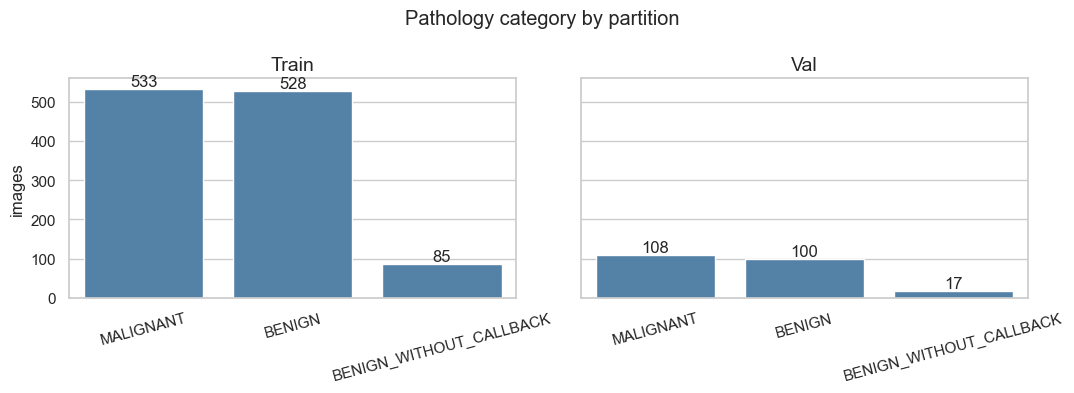

,images,malignant,benign,malignant share,majority-class accuracy,benign without callback
partition,,,,,,
Train,1146,533,613,0.465,0.535,85
Val,225,108,117,0.480,0.520,17


[data_loader] Class counts (train): {0: 613, 1: 533}
[data_loader] Class weights:        {0: 0.9347471451876019, 1: 1.075046904315197}


In [12]:
fig, axes = plt.subplots(1, len(PARTITIONS), figsize=(11, 4), sharey=True)
for ax, (name, df) in zip(axes, PARTITIONS.items()):
    counts = df["pathology"].value_counts()
    sns.barplot(x=counts.index, y=counts.values, color="steelblue", ax=ax)
    ax.bar_label(ax.containers[0])
    ax.set_title(name)
    ax.set_xlabel("")
    ax.set_ylabel("images")
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Pathology category by partition")
fig.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "class_distribution.png")
plt.show()

rows = []
for name, df in PARTITIONS.items():
    n, n_mal = len(df), int(df["label"].sum())
    rows.append(
        {
            "partition": name,
            "images": n,
            "malignant": n_mal,
            "benign": n - n_mal,
            "malignant share": n_mal / n,
            "majority-class accuracy": max(n_mal, n - n_mal) / n,
            "benign without callback": int((df["pathology"] == "BENIGN_WITHOUT_CALLBACK").sum()),
        }
    )
label_balance = pd.DataFrame(rows).set_index("partition")
display(label_balance.round(3))

class_weights = dl.compute_class_weights(train_df)

### 5.2 Three prevalences

Three malignancy rates matter to this project, and they run from about one in two to about one in a hundred [6].

1. **This dataset.** The malignant share of images in the test partition, from the pipeline's record: the rate at which the models are evaluated. The training partition's share differs from it (section 4.2).
2. **The assessment clinic.** Women recalled from screening for further work-up. CBIS-DDSM resembles this population: every case has a finding that someone judged worth investigating.
3. **The screening population.** All women screened, almost all of whom have normal breasts. No figure in this project is a screening figure.

The two clinical rates come from the NHS Breast Screening Programme statistics for England, 2024-25 [6]: women aged 45 and over who were screened, referred for assessment, and found to have cancer. The values are defined once, in `config.PREVALENCE`, and `src/analysis.py` uses them to re-weight predictive values and the decision curve. The cell recomputes them from the source counts and checks them against `config`.

,malignancy rate
cbis_test,0.4796
nhs_assessment,0.2626
nhs_screening,0.0090


This dataset against the assessment clinic: 1.8 times
This dataset against the screening population: 53 times


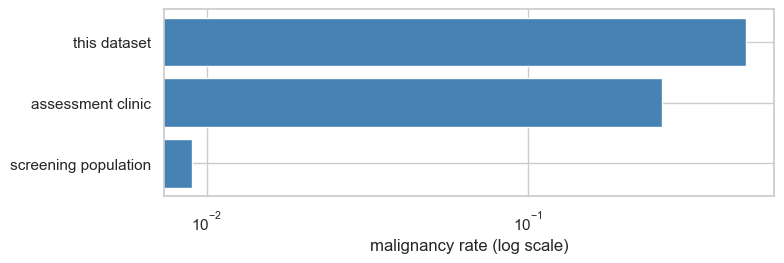

In [13]:
# NHS Breast Screening Programme, England, 2024-25 [6]; women aged 45 and over.
# The screened count is published as 2.15 million (rounded).
NHS_SCREENED, NHS_RECALLED, NHS_CANCERS = 2_150_000, 73_451, 19_291

expected = {
    "cbis_test": recorded["test"]["images_malignant"] / recorded["test"]["images"],
    "nhs_assessment": NHS_CANCERS / NHS_RECALLED,
    "nhs_screening": NHS_CANCERS / NHS_SCREENED,
}
for key, value in expected.items():
    assert abs(config.PREVALENCE[key] - value) < 1e-4, f"PREVALENCE['{key}'] is off its source"

prevalence = pd.Series(config.PREVALENCE, name="malignancy rate")
show(prevalence.to_frame(), {"malignancy rate": "{:.4f}"})
against_clinic = prevalence["cbis_test"] / prevalence["nhs_assessment"]
against_screening = prevalence["cbis_test"] / prevalence["nhs_screening"]
print(f"This dataset against the assessment clinic: {against_clinic:.1f} times")
print(f"This dataset against the screening population: {against_screening:.0f} times")

fig, ax = plt.subplots(figsize=(8, 2.8))
labels = ["this dataset", "assessment clinic", "screening population"]
ax.barh(labels, prevalence[["cbis_test", "nhs_assessment", "nhs_screening"]], color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("malignancy rate (log scale)")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "prevalence.png")
plt.show()

## 6. Clinical descriptors

Each mass carries descriptors assigned by a radiologist. The models never see them; they take the image alone. The descriptors matter here for three reasons.

- **Mass shape and margins** are important predictors of whether a mass is benign or malignant [1], [7]. How strongly they separate the classes shows how much signal a reader finds in these images.
- **Assessment** is the radiologist's BI-RADS category. It is the basis of the specialist baseline the models are compared with (section 8).
- **Subtlety** is a radiologist's rating of how hard the abnormality is to see, on a scale of 1 to 5 [1], where 1 is subtle and 5 is obvious [4]. A few rows hold a 0, which is not a rating on that scale. The evaluation reports results by subtlety.

At image level an image with several masses keeps one mass's shape and margins, the highest assessment and the lowest subtlety (section 1).

### 6.1 Distributions

For each descriptor: how many training images fall in each category, and the malignant share of each. The dashed line is the malignant share of the whole training partition.

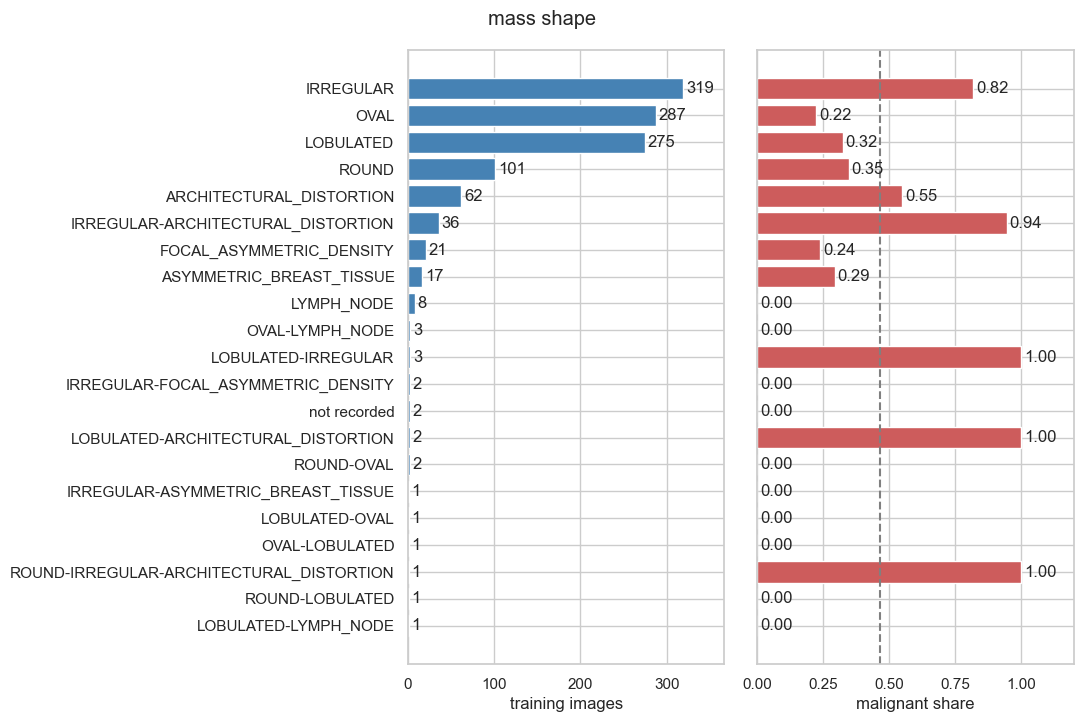

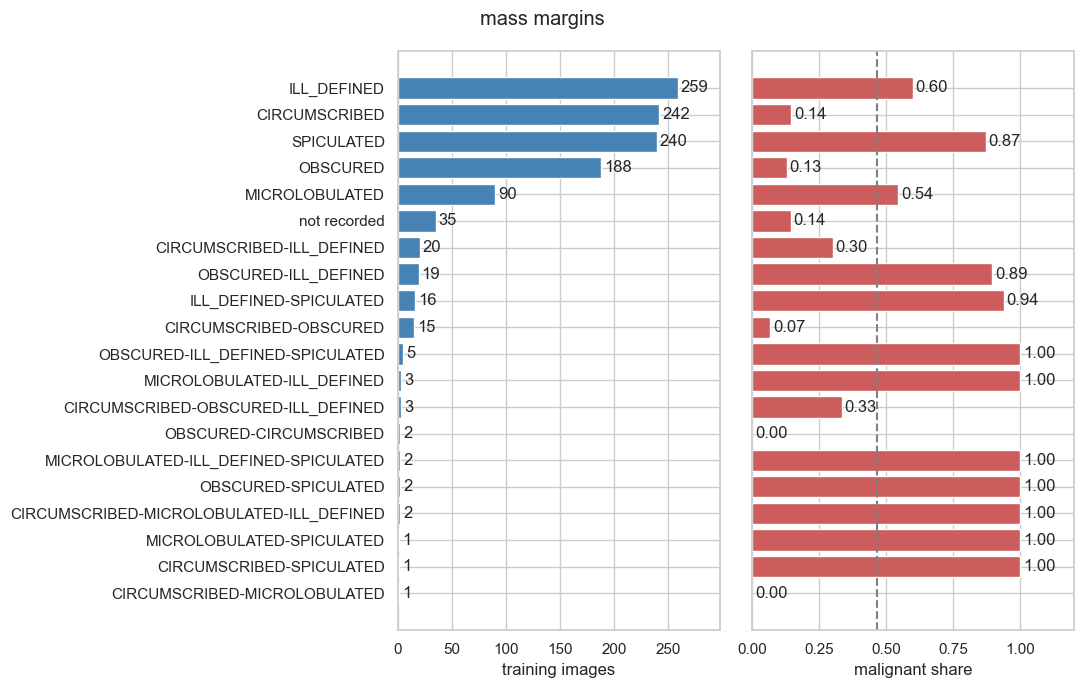

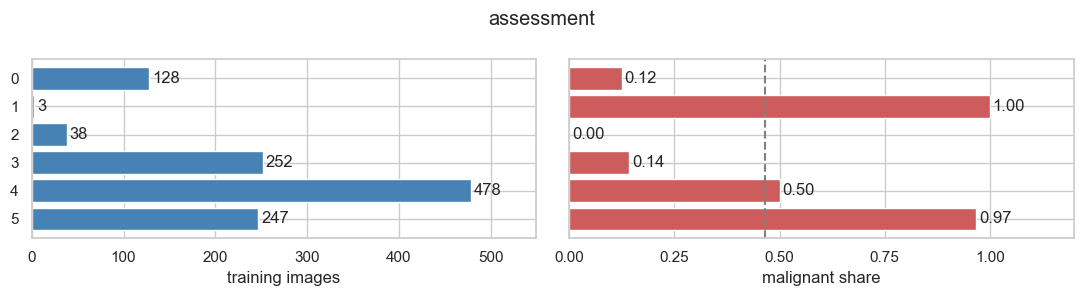

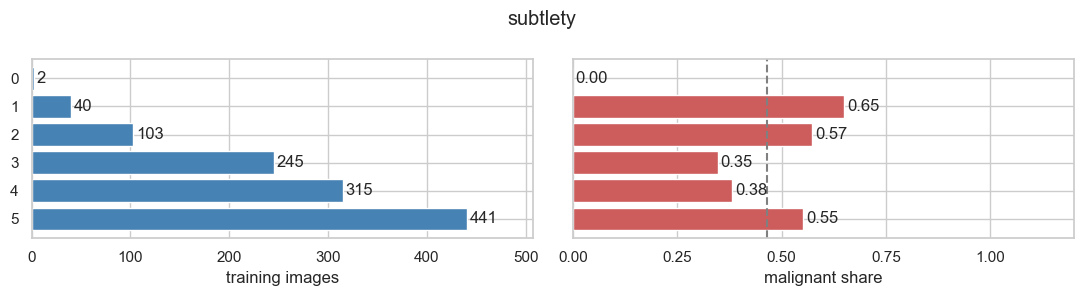

In [14]:
def plot_descriptor(df: pd.DataFrame, col: str, ordinal: bool) -> None:
    d = df[[col, "label"]].copy()
    d[col] = d[col].astype("object").where(d[col].notna(), "not recorded").astype(str)
    g = d.groupby(col)["label"].agg(n="size", share="mean")
    g = g.sort_index(ascending=False) if ordinal else g.sort_values("n")

    fig, (left, right) = plt.subplots(1, 2, figsize=(11, max(3, 0.35 * len(g))), sharey=True)
    left.barh(g.index, g["n"], color="steelblue")
    left.bar_label(left.containers[0], padding=2)
    left.set_xlim(0, g["n"].max() * 1.15)
    left.set_xlabel("training images")
    right.barh(g.index, g["share"], color="indianred")
    right.axvline(df["label"].mean(), color="grey", linestyle="--")
    right.bar_label(right.containers[0], fmt="%.2f", padding=2)
    right.set_xlim(0, 1.2)
    right.set_xticks([0, 0.25, 0.5, 0.75, 1])
    right.set_xlabel("malignant share")
    fig.suptitle(col)
    fig.tight_layout()
    fig.savefig(CONFIG["figures_dir"] / f"descriptor_{col.replace(' ', '_')}.png")
    plt.show()


for col in CONFIG["clinical_cols"]:
    plot_descriptor(train_df, col, ordinal=col in ("assessment", "subtlety"))

### 6.2 Strength of association with the label

Cramér's V measures how strongly a descriptor is associated with the label, from 0 (none) to 1 (complete). It is the figure to read. The p-values are shown for completeness, but with over a thousand images almost any difference is significant, and images of one patient are not independent, which makes the p-values optimistic. Categories with fewer than ten images are pooled as "other" so that the chi-square test is not driven by sparse cells.

For the two ordinal descriptors, the Mann-Whitney test keeps the ordering that chi-square discards. The rank-biserial correlation is positive when malignant masses score higher. A value of 0 lies outside both scales: for assessment it means "incomplete" (section 8), and for subtlety it is not a rating. Rows holding it are left out of this test.

In [15]:
def association(df: pd.DataFrame, col: str, min_count: int = 10) -> dict:
    d = df[[col, "label"]].dropna()
    values = d[col].astype(str)
    values = values.mask(values.map(values.value_counts()) < min_count, "other")
    table = pd.crosstab(values, d["label"])
    chi2, p, dof, _ = chi2_contingency(table)
    v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
    return {
        "descriptor": col,
        "images": len(d),
        "categories": len(table),
        "chi2": chi2,
        "dof": dof,
        "p": p,
        "Cramér's V": v,
    }


V_FORMATS = {"chi2": "{:.1f}", "p": "{:.2g}", "Cramér's V": "{:.3f}"}

rows = [association(train_df, col) for col in CONFIG["clinical_cols"]]
associations = pd.DataFrame(rows).set_index("descriptor")
show(associations, V_FORMATS)

rows = []
for col in ("assessment", "subtlety"):
    d = train_df[train_df[col] != 0]
    malignant = d.loc[d["label"] == 1, col].dropna()
    benign = d.loc[d["label"] == 0, col].dropna()
    u, p = mannwhitneyu(malignant, benign, alternative="two-sided")
    rows.append(
        {
            "descriptor": col,
            "malignant mean": malignant.mean(),
            "benign mean": benign.mean(),
            "rank-biserial r": 2 * u / (len(malignant) * len(benign)) - 1,
            "p": p,
        }
    )
ordinal_tests = pd.DataFrame(rows).set_index("descriptor")
ordinal_formats = {
    "malignant mean": "{:.2f}",
    "benign mean": "{:.2f}",
    "rank-biserial r": "{:+.3f}",
    "p": "{:.2g}",
}
show(ordinal_tests, ordinal_formats)

,images,categories,chi2,dof,p,Cramér's V
descriptor,,,,,,
mass shape,1144,9,302.3,8,1.3e-60,0.514
mass margins,1111,10,412.7,9,2.7e-83,0.609
assessment,1146,6,454.2,5,6e-96,0.630
subtlety,1146,6,47.8,5,3.8e-09,0.204


,malignant mean,benign mean,rank-biserial r,p
descriptor,,,,
assessment,4.38,3.43,+0.647,4.5e-82
subtlety,3.93,3.85,+0.083,0.011


### 6.3 Training against validation

If the descriptors were distributed differently in the two partitions, validation results would describe a different kind of case from the one the models trained on. The tables give each category's share in both.

In [16]:
def category_shares(df: pd.DataFrame, col: str) -> pd.Series:
    values = df[col].astype("object").where(df[col].notna(), "not recorded").astype(str)
    return values.value_counts(normalize=True)


for col in CONFIG["clinical_cols"]:
    shares = pd.DataFrame({name: category_shares(df, col) for name, df in PARTITIONS.items()})
    shares = shares.fillna(0)
    shares["difference"] = shares["Val"] - shares["Train"]
    print(col)
    display(shares.sort_values("Train", ascending=False).round(3))

mass shape


,Train,Val,difference
mass shape,,,
IRREGULAR,0.278,0.280,0.002
OVAL,0.250,0.231,-0.019
LOBULATED,0.240,0.222,-0.018
ROUND,0.088,0.080,-0.008
ARCHITECTURAL_DISTORTION,0.054,0.076,0.021
IRREGULAR-ARCHITECTURAL_DISTORTION,0.031,0.027,-0.005
FOCAL_ASYMMETRIC_DENSITY,0.018,0.009,-0.009
ASYMMETRIC_BREAST_TISSUE,0.015,0.022,0.007
LYMPH_NODE,0.007,0.036,0.029


mass margins


,Train,Val,difference
mass margins,,,
ILL_DEFINED,0.226,0.236,0.010
CIRCUMSCRIBED,0.211,0.191,-0.020
SPICULATED,0.209,0.271,0.062
OBSCURED,0.164,0.151,-0.013
MICROLOBULATED,0.079,0.062,-0.016
not recorded,0.031,0.036,0.005
CIRCUMSCRIBED-ILL_DEFINED,0.017,0.000,-0.017
OBSCURED-ILL_DEFINED,0.017,0.009,-0.008
ILL_DEFINED-SPICULATED,0.014,0.018,0.004


assessment


,Train,Val,difference
assessment,,,
4,0.417,0.431,0.014
3,0.220,0.138,-0.082
5,0.216,0.289,0.073
0,0.112,0.071,-0.041
2,0.033,0.071,0.038
1,0.003,0.000,-0.003


subtlety


,Train,Val,difference
subtlety,,,
5,0.385,0.427,0.042
4,0.275,0.244,-0.030
3,0.214,0.213,-0.000
2,0.090,0.071,-0.019
1,0.035,0.044,0.010
0,0.002,0.000,-0.002


## 7. Breast density

Density is recorded for every case on the four-point BI-RADS scale, coded 1 to 4 in the dataset [1]: 1 almost entirely fatty, 2 scattered areas of fibroglandular density, 3 heterogeneously dense, 4 extremely dense. The 5th edition of the atlas labels the same four categories a to d [7]. The sensitivity of mammography for noncalcified lesions falls as density rises, and the denser the breast, the larger the lesions that may be obscured [7]. A classifier may degrade in the same way, so the evaluation reports results by density.

### 7.1 Distribution

Counts per category in the training and validation partitions, and each category's share of its partition. The extremely dense category is small, so any result reported for it rests on few cases.

,Train,Val
breast_density,,
1 almost entirely fatty,193,50
2 scattered,509,99
3 heterogeneously dense,329,58
4 extremely dense,115,18


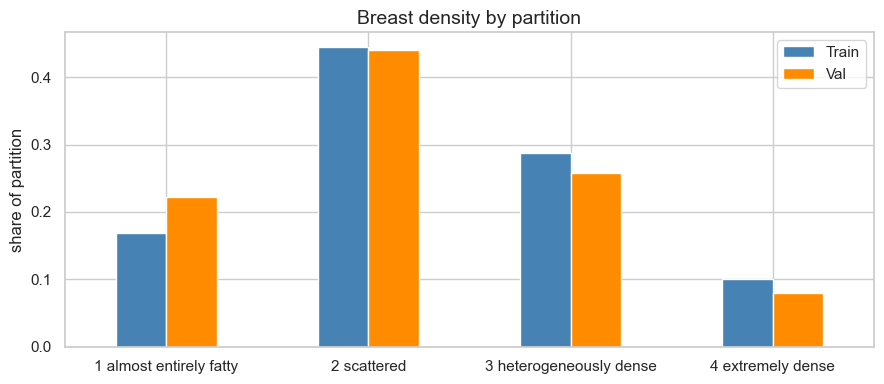

In [17]:
DENSITY_NAMES = {
    1: "1 almost entirely fatty",
    2: "2 scattered",
    3: "3 heterogeneously dense",
    4: "4 extremely dense",
}

counts = {name: df["breast_density"].value_counts().sort_index() for name, df in PARTITIONS.items()}
density_counts = pd.DataFrame(counts).fillna(0).astype(int)
display(density_counts.rename(index=DENSITY_NAMES))

density_shares = density_counts / density_counts.sum()
named_shares = density_shares.rename(index=DENSITY_NAMES)
ax = named_shares.plot.bar(figsize=(9, 4), color=["steelblue", "darkorange"], rot=0)
ax.set_xlabel("")
ax.set_ylabel("share of partition")
ax.set_title("Breast density by partition")
plt.tight_layout()
plt.savefig(CONFIG["figures_dir"] / "density_by_partition.png")
plt.show()

### 7.2 Association with the label

In a screening population, density is linked both to cancer risk and to missed cancers. This dataset is not such a population: every case was selected because it already had a suspicious mass. Whether density still says anything about the label here is an empirical question, and the cell answers it with the same measures as section 6: the malignant share per category, Cramér's V, and the Mann-Whitney test on the ordered scale.

A weak association would mean a model cannot gain much from reading density as a shortcut to the label. It would say nothing about whether density makes masses harder to classify; that is a question for the evaluation.

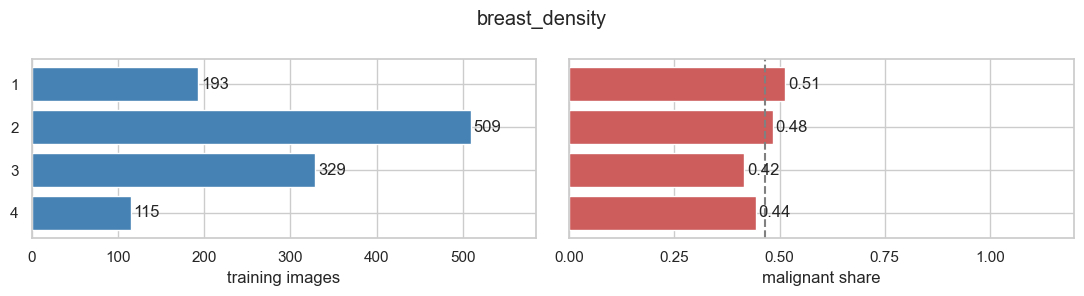

,images,categories,chi2,dof,p,Cramér's V
descriptor,,,,,,
breast_density,1146,4,5.8,3,0.12,0.071


Mann-Whitney: rank-biserial r = -0.071, p = 0.028


In [18]:
plot_descriptor(train_df, "breast_density", ordinal=True)

rows = [association(train_df, "breast_density")]
density_association = pd.DataFrame(rows).set_index("descriptor")
show(density_association, V_FORMATS)

malignant = train_df.loc[train_df["label"] == 1, "breast_density"]
benign = train_df.loc[train_df["label"] == 0, "breast_density"]
u, p = mannwhitneyu(malignant, benign, alternative="two-sided")
r = 2 * u / (len(malignant) * len(benign)) - 1
print(f"Mann-Whitney: rank-biserial r = {r:+.3f}, p = {p:.2g}")

## 8. The BI-RADS assessment

The `assessment` column is the radiologist's BI-RADS category for the mass [7]: 1 negative, 2 benign, 3 probably benign, 4 suspicious, 5 highly suggestive of malignancy. Read as an ordered score it is a classifier in its own right, made by a specialist, and the project uses it as the specialist baseline that the models are compared with. The radiologist had more to go on than the models do: both views, the whole breast and the clinical context.

### 8.1 Assessment 0

The column also holds the value 0. BI-RADS 0 does not mean "less suspicious than 1". It means the assessment is incomplete: additional imaging evaluation and/or prior mammograms for comparison are needed [7]. It sits outside the ordering, not at the bottom of it. The cell counts the images at each value and shows the malignant share of each, so the position of category 0 can be seen against the ordered categories.

In [19]:
tables = []
for name, df in PARTITIONS.items():
    g = df.groupby("assessment")["label"].agg(images="size", malignant="sum")
    g["malignant share"] = g["malignant"] / g["images"]
    tables.append(g.assign(partition=name).reset_index())
assessment_audit = pd.concat(tables).pivot(
    index="assessment", columns="partition", values=["images", "malignant share"]
)
display(assessment_audit.round(3))

for name, df in PARTITIONS.items():
    zero = df[df["assessment"] == 0]
    share, malignant = len(zero) / len(df), zero["label"].mean()
    print(f"{name}: {len(zero)} images at assessment 0 ({share:.1%}), {malignant:.1%} malignant")

images       malignant share       
partition   Train   Val           Train    Val
assessment                                    
0           128.0  16.0           0.125  0.000
1             3.0   NaN           1.000    NaN
2            38.0  16.0           0.000  0.000
3           252.0  31.0           0.143  0.129
4           478.0  97.0           0.500  0.412
5           247.0  65.0           0.968  0.985

Train: 128 images at assessment 0 (11.2%), 12.5% malignant
Val: 16 images at assessment 0 (7.1%), 0.0% malignant


### 8.2 The specialist baseline

Ranking the assessment-0 images lowest would treat "not yet assessed" as "least suspicious". The baseline therefore leaves them out: it is the assessment, as an ordered score, on the images that have a category from 1 to 5. At BI-RADS 4 and 5 a biopsy is recommended [7], and that threshold gives the baseline its sensitivity and specificity. Nothing is fitted.

The choice rests on what the category means, not on which reading scores best. The first table shows how much it matters: the area under the ROC curve under three readings of category 0. The second table gives the baseline as the pipeline computed and stored it (`src/birads_baseline.py`), with a patient-level bootstrap interval for the area under the curve and Wilson intervals for sensitivity and specificity, and the cell checks that the value computed here agrees with it.

A paired comparison needs both readers on the same images, so every model is compared with the baseline on these images only. The last table gives the size of that comparison set in each partition. The value of the baseline on the test partition belongs to the results and is reported with them.

In [20]:
def readings(df: pd.DataFrame) -> dict[str, pd.Series]:
    a = df["assessment"].astype(float)
    return {"0 as recorded": a, "0 excluded": a.where(a != 0), "0 read as 4": a.where(a != 0, 4.0)}


rows = []
for name, df in PARTITIONS.items():
    for reading, score in readings(df).items():
        keep = score.notna()
        auc = roc_auc_score(df.loc[keep, "label"], score[keep])
        rows.append({"partition": name, "reading": reading, "images": int(keep.sum()), "AUC": auc})
by_reading = pd.DataFrame(rows)
reading_table = by_reading.pivot(index="reading", columns="partition", values=["images", "AUC"])
display(reading_table.round(4))

with open(PROJECT_ROOT / "artifacts" / "birads_baseline.json") as f:
    stored = json.load(f)["per_partition"]

keys = ["n_full", "n_excluded_birads0", "n", "auc_roc", "auc_roc_ci"]
keys += ["sens", "sens_ci", "spec", "spec_ci"]
baseline = pd.DataFrame({part: {k: stored[part][k] for k in keys} for part in ("train", "val")}).T
display(baseline)

live = by_reading.query("reading == '0 excluded'").set_index("partition")
for name, part in (("Train", "train"), ("Val", "val")):
    gap = abs(live.loc[name, "AUC"] - stored[part]["auc_roc"])
    assert gap < 1e-3, f"{part}: AUC differs from the stored baseline"
    n_recorded = recorded[part]["birads_comparison"]
    assert live.loc[name, "images"] == n_recorded, f"{part}: comparison-set size differs"
print("The baseline computed here agrees with the stored one.")

comparison = pd.DataFrame(recorded).T[["images", "birads_comparison"]]
comparison["excluded"] = comparison["images"] - comparison["birads_comparison"]
display(comparison)

images            AUC        
partition       Train    Val   Train     Val
reading                                     
0 as recorded  1146.0  225.0  0.8328  0.8814
0 excluded     1018.0  209.0  0.8235  0.8627
0 read as 4    1146.0  225.0  0.7968  0.8511

,n_full,n_excluded_birads0,n,auc_roc,auc_roc_ci,sens,sens_ci,spec,spec_ci
train,1146,128,1018,0.823519,"[0.793839929681487, 0.8559525604595312]",0.924565,"[0.8985378627196062, 0.9443289877659103]",0.506986,"[0.46332162144614863, 0.550544117743194]"
val,225,16,209,0.86267,"[0.8103445838587285, 0.9089353968099592]",0.962963,"[0.9086183563719779, 0.9855044586630923]",0.425743,"[0.3337769739431524, 0.523149854732554]"


The baseline computed here agrees with the stored one.


,images,birads_comparison,excluded
train,1146,1018,128
val,225,209,16
test,221,203,18


### 8.3 Where assessment and pathology disagree

Two kinds of disagreement, on the images with a category from 1 to 5.

- **Benign masses assessed 4 or 5.** The assessment recommends a biopsy and the mass is recorded as benign. They are the reason the baseline's specificity is low, and the table gives their share of all benign masses.
- **Malignant masses assessed 1 or 2.** Cancers the recorded assessment would have passed. The cell also compares their subtlety with that of the cancers assessed 4 or 5, to see whether they were missed because they were hard to see.

The second group is small, so its size and its subtlety vary between partitions by chance. It is a description, not a finding.

In [21]:
rows = []
for name, df in PARTITIONS.items():
    d = df[df["assessment"] != 0]
    malignant, benign = d[d["label"] == 1], d[d["label"] == 0]
    passed = malignant[malignant["assessment"] <= 2]
    caught = malignant[malignant["assessment"] >= 4]
    alarms = benign[benign["assessment"] >= 4]
    rows.append(
        {
            "partition": name,
            "benign": len(benign),
            "benign assessed 4-5": len(alarms),
            "share of benign": len(alarms) / len(benign),
            "malignant": len(malignant),
            "malignant assessed 1-2": len(passed),
            "share of malignant": len(passed) / len(malignant),
            "mean subtlety, assessed 1-2": passed.loc[passed["subtlety"] != 0, "subtlety"].mean(),
            "mean subtlety, assessed 4-5": caught.loc[caught["subtlety"] != 0, "subtlety"].mean(),
        }
    )
display(pd.DataFrame(rows).set_index("partition").round(3))

,benign,benign assessed 4-5,share of benign,malignant,malignant assessed 1-2,share of malignant,"mean subtlety, assessed 1-2","mean subtlety, assessed 4-5"
partition,,,,,,,,
Train,501,247,0.493,517,3,0.006,1.667,3.996
Val,101,58,0.574,108,0,0.000,NaN,4.115


## 9. View coverage

A standard mammographic examination images each breast in two projections, craniocaudal (CC) and mediolateral oblique (MLO). A model that reads both views of a mass needs both to be present in the dataset.

### 9.1 Views per breast

For each patient and breast: whether the dataset holds a CC image, an MLO image, or both. This counts views that carry a mass annotation, not views that were taken. A mass annotated on the CC view only appears here as CC only, even though an MLO film was made.

In [22]:
def views_per_breast(df: pd.DataFrame) -> pd.Series:
    assert set(df["image view"]) <= set(CONFIG["valid_views"]), "Unexpected view name"
    views = df.groupby(["patient_id", "left or right breast"])["image view"].agg(set)
    both = int(views.map(lambda v: v == {"CC", "MLO"}).sum())
    cc_only = int(views.map(lambda v: v == {"CC"}).sum())
    mlo_only = int(views.map(lambda v: v == {"MLO"}).sum())
    counts = {"breasts": len(views), "CC and MLO": both, "CC only": cc_only, "MLO only": mlo_only}
    return pd.Series(counts)


view_coverage = pd.DataFrame({name: views_per_breast(df) for name, df in PARTITIONS.items()}).T
view_coverage["share with both"] = view_coverage["CC and MLO"] / view_coverage["breasts"]
display(view_coverage.round(3))

,breasts,CC and MLO,CC only,MLO only,share with both
Train,672,474,60,138,0.705
Val,132,93,14,25,0.705


### 9.2 The lesion pairs used by the two-view models

The two-view models do not pair images; they pair lesions. A pair is one mass on the CC view and one on the MLO view of the same patient and breast, accepted in one of two cases: each view shows exactly one mass, or the two masses carry the same abnormality number. Pairs whose two labels disagree are dropped. `src/fusion.py` builds the pairs and stores them in `artifacts/`, and the table reads them from there. For the test partition only the number of pairs is read.

Two things to take from the table. First, the pairs cover only part of the lesions, so a two-view model can be evaluated on that part only. Second, the pairs are chosen by a rule, not at random: most come from breasts that show a single mass in each view. The table compares the malignant share of the pairs with that of all lesions, which shows whether the rule selects on the label. Whether it selects on difficulty is something only model results can show. Either way, results on the pairs describe this subset and cannot stand in for results on all lesions.


In [23]:
ARTIFACTS = PROJECT_ROOT / "artifacts"

rows = []
for part in PARTS:
    path = ARTIFACTS / f"fusion_pairs_view_{part}.csv"
    record = recorded[part]
    row = {"partition": part, "lesions": record["lesions"]}
    if part == "test":
        with open(path) as f:
            row["pairs"] = sum(1 for _ in f) - 1
    else:
        pairs = pd.read_csv(path)
        in_pairs = pd.concat([pairs["lesion_id_a"], pairs["lesion_id_b"]])
        assert in_pairs.is_unique, f"{part}: a lesion appears in more than one pair"
        row["pairs"] = len(pairs)
        row["one mass per view"] = int((pairs["pair_kind"] == "single_mass").sum())
        row["same abnormality number"] = int((pairs["pair_kind"] == "id_match").sum())
        row["malignant share, pairs"] = pairs["label"].mean()
        row["malignant share, all lesions"] = record["lesions_malignant"] / record["lesions"]
    rows.append(row)

pair_table = pd.DataFrame(rows).set_index("partition")
kinds = ["one mass per view", "same abnormality number"]
pair_table[kinds] = pair_table[kinds].astype("Int64")
pair_table["share of lesions in a pair"] = 2 * pair_table["pairs"] / pair_table["lesions"]
display(pair_table.round(3))

,lesions,pairs,one mass per view,same abnormality number,"malignant share, pairs","malignant share, all lesions",share of lesions in a pair
partition,,,,,,,
train,1210,491,447,44,0.462,0.462,0.812
val,243,100,87,13,0.470,0.461,0.823
test,243,101,<NA>,<NA>,NaN,NaN,0.831


## 10. Sample images

Six training mammograms, three benign and three malignant, each with the outline of its mass drawn from the lesion mask. The images are decoded by the loader's own function and, for display, windowed between their 1st and 99th percentiles. The figure serves three checks: the files decode with the breast bright on a dark background, the labels and descriptors belong to the images, and the mask lines up with the mammogram.

It also shows the difficulty that shapes the whole project. The mass is a small object in a very large image, and the difference between a benign and a malignant mass lies in the detail of its shape and margin. `02_lesion_geometry` measures how small.

Some masses are too small to make out at the scale of this figure, and some films show bright edges, view markers or bands. Both are part of what the models are given.

Only images with a single mass are sampled, so that the outline and the label refer to the same lesion.

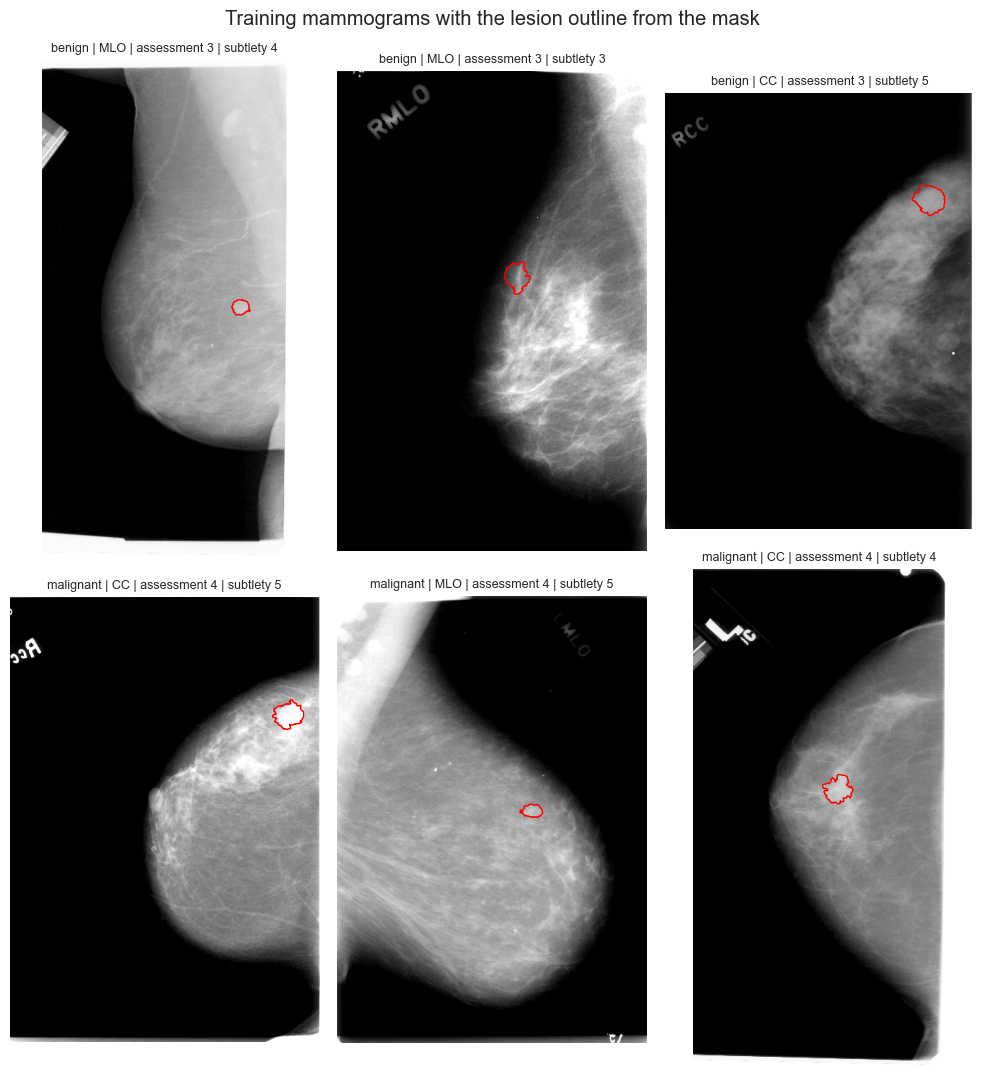

In [24]:
full_lookup = dl._build_combined_lookup(CONFIG["train_img_dir"], CONFIG["test_img_dir"])
full_lookup = {Path(k).parts[0]: v for k, v in full_lookup.items()}


def resample(arr: np.ndarray, shape: tuple[int, int]) -> np.ndarray:
    rows = np.linspace(0, arr.shape[0] - 1, shape[0]).astype(int)
    cols = np.linspace(0, arr.shape[1] - 1, shape[1]).astype(int)
    return arr[np.ix_(rows, cols)]


single = train_df[train_df["n_abnormalities"] == 1]
sample = single.groupby("label").sample(3, random_state=SEED).to_dict("records")

fig, axes = plt.subplots(2, 3, figsize=(10, 11))
for ax, row in zip(axes.ravel(), sample):
    image = np.squeeze(dl._read_full(str(full_lookup[row["image_id"]])))
    image = dl._normalise_intensity(image, "percentile")[::8, ::8]
    mask = pydicom.dcmread(mask_lookup[row["lesion_id"]]).pixel_array
    mask = resample(mask > 0.5 * mask.max(), image.shape).astype(float)

    ax.imshow(image, cmap="gray")
    ax.contour(mask, levels=[0.5], colors="red", linewidths=1)
    kind = "malignant" if row["label"] == 1 else "benign"
    view, assessment, subtlety = row["image view"], row["assessment"], row["subtlety"]
    ax.set_title(f"{kind} | {view} | assessment {assessment} | subtlety {subtlety}", fontsize=9)
    ax.axis("off")

fig.suptitle("Training mammograms with the lesion outline from the mask")
fig.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "sample_images.png")
plt.show()

## 11. DICOM header audit

Two header attributes decide how a mammogram has to be decoded, so both are checked on every file before any preprocessing is designed.

- **Photometric interpretation.** `MONOCHROME2` stores tissue bright on a dark background; `MONOCHROME1` stores the reverse. A dataset that mixed the two without correction would present the model with contradictory images of the same tissue.
- **Bits stored.** The bit depth fixes the divisor that maps pixel values to the range 0 to 1. The whole-image path divides by 65,535, which is right only if every image is 16-bit.

The audit also records whether the files carry a pixel spacing. Without it, the size of a lesion can be given in pixels but not in millimetres.

The audit reads headers only, for every mammogram in both official folders, and checks that the files on disk are the images the case files describe.

In [25]:
rows, unreadable = [], 0
for img_dir in (CONFIG["train_img_dir"], CONFIG["test_img_dir"]):
    for p in img_dir.glob("**/*.dcm"):
        try:
            ds = pydicom.dcmread(p, stop_before_pixels=True)
        except Exception:
            unreadable += 1
            continue
        rows.append(
            {
                "image_id": p.parent.relative_to(img_dir).parts[0],
                "photometric": str(ds.PhotometricInterpretation),
                "bits_stored": int(ds.BitsStored),
                "bits_allocated": int(ds.BitsAllocated),
                "rows": int(ds.Rows),
                "cols": int(ds.Columns),
                "pixel_spacing": hasattr(ds, "PixelSpacing") or hasattr(ds, "ImagerPixelSpacing"),
            }
        )

image_meta = pd.DataFrame(rows)
described = set(raw[IMG_COL].map(lambda s: Path(str(s)).parts[0]))
print(f"Mammogram files read: {len(image_meta):,} | unreadable headers: {unreadable}")
print(f"Images described by the case files: {len(described):,}")
assert set(image_meta["image_id"]) == described, "Files on disk and case files differ"
assert image_meta["image_id"].is_unique, "An image has more than one DICOM file"

for col in ("photometric", "bits_stored", "bits_allocated"):
    print(f"\n{col}:")
    print(image_meta[col].value_counts().rename_axis(None).to_string())
print(f"\nFiles with a pixel spacing: {int(image_meta['pixel_spacing'].sum())}")

assert (image_meta["bits_stored"] == 16).all(), "Not every image is 16-bit"

Mammogram files read: 1,592 | unreadable headers: 0
Images described by the case files: 1,592

photometric:
MONOCHROME2    1592

bits_stored:
16    1592

bits_allocated:
16    1592

Files with a pixel spacing: 0


## 12. Image resolution

### 12.1 Size distribution

The mammograms are scanned films and far larger than any input a convolutional network can take. The histograms show their height and width in pixels. The heights fall into separate clusters. The original films were digitised on scanners of more than one make, and the clusters are likely to reflect that (section 12.2 asks whether it matters).

The table puts the sizes against the two inputs this project feeds with whole mammograms: the 224 × 224 whole-image classifier, which pads the image to a square first, and the 1024 × 576 canvas of the localiser. It gives the reduction in scale, as the number of mammogram pixels along each axis that are merged into one input pixel, and the share of the input that is padding. A mass a few hundred pixels across keeps little of its margin at the first of these scales. That loss is the reason the project locates the mass and classifies a crop of it. `02_lesion_geometry` works out the sizes lesion by lesion.

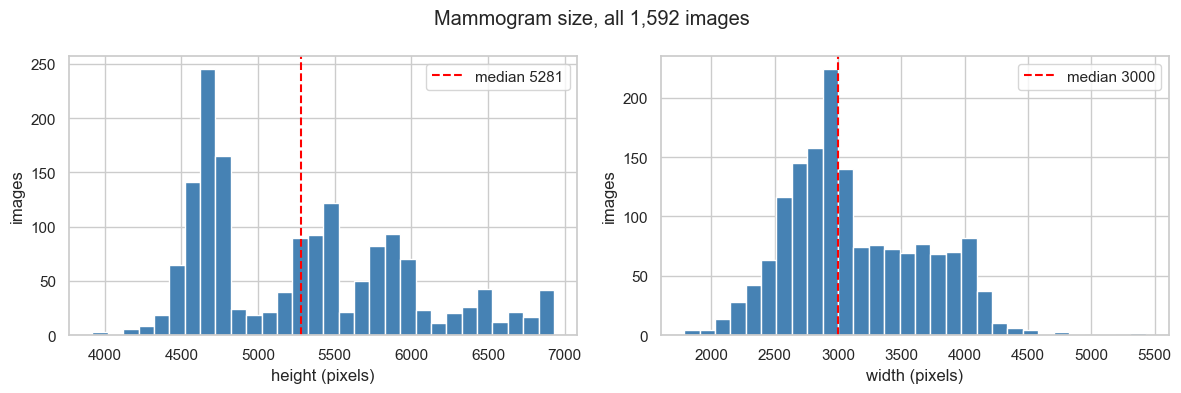

,"mammogram pixels per input pixel, along each axis (median)",share of input that is padding (median)
input,,
"whole-image classifier, 224 x 224",23.58,0.41
"localiser, 1024 x 576",5.36,0.10


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in ((axes[0], "rows", "height"), (axes[1], "cols", "width")):
    values = image_meta[col]
    ax.hist(values, bins=30, color="steelblue")
    ax.axvline(values.median(), color="red", linestyle="--", label=f"median {values.median():.0f}")
    ax.set_xlabel(f"{label} (pixels)")
    ax.set_ylabel("images")
    ax.legend()
fig.suptitle(f"Mammogram size, all {len(image_meta):,} images")
fig.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "resolution.png")
plt.show()

h, w = image_meta["rows"], image_meta["cols"]
long_side = np.maximum(h, w)
side = CONFIG["target_size"][0]
canvas_h, canvas_w = config.LOC_INPUT_H, config.LOC_INPUT_W
canvas_ratio = np.maximum(h / canvas_h, w / canvas_w)

SCALE_COL = "mammogram pixels per input pixel, along each axis (median)"
PADDING_COL = "share of input that is padding (median)"
whole_padding = 1 - h * w / long_side**2
canvas_padding = 1 - (h / canvas_ratio) * (w / canvas_ratio) / (canvas_h * canvas_w)

inputs = pd.DataFrame(
    {
        SCALE_COL: [(long_side / side).median(), canvas_ratio.median()],
        PADDING_COL: [whole_padding.median(), canvas_padding.median()],
    },
    index=[f"whole-image classifier, {side} x {side}", f"localiser, {canvas_h} x {canvas_w}"],
)
inputs.index.name = "input"
display(inputs.round(2))

### 12.2 Scanner type against the label

If images from one scanner were mostly malignant and images from another mostly benign, a model could learn to recognise the scanner and appear to recognise cancer. Image height serves as a rough stand-in for scanner type: images taller than the median against the rest. The test uses the labelled training and validation images, and the same measure of association as section 6.

In [27]:
labelled = pd.concat([train_df, val_df])[["image_id", "label"]]
labelled = labelled.merge(image_meta[["image_id", "rows"]], on="image_id")
labelled["taller than median"] = labelled["rows"] > image_meta["rows"].median()

display(pd.crosstab(labelled["taller than median"], labelled["label"]))
rows = [association(labelled, "taller than median")]
scanner_association = pd.DataFrame(rows).set_index("descriptor")
show(scanner_association, V_FORMATS)

label,0,1
taller than median,,
False,357,329
True,373,312


,images,categories,chi2,dof,p,Cramér's V
descriptor,,,,,,
taller than median,1371,2,0.7,1,0.4,0.023


### 12.3 Mask and mammogram on one grid

A box read from a lesion mask is applied to the mammogram, and the localiser learns mask targets against mammogram pixels. Both assume the two images share a pixel grid. The cell compares the size of every mask with the size of its mammogram, from the headers.

Where the sizes differ, the cell reports the ratio on each axis. If the two ratios agree, the mask is a uniformly scaled copy, and a box can be carried over by multiplying its coordinates by that ratio. `02_lesion_geometry` does this for each lesion.

In [28]:
lesions = pd.DataFrame(
    {
        "lesion_dir": raw["ROI mask file path"].map(lambda s: Path(str(s)).parts[0]),
        "image_id": raw[IMG_COL].map(lambda s: Path(str(s)).parts[0]),
    }
)
masks = roi_meta.loc[roi_meta["bits"] == 8, ["lesion_dir", "rows", "cols"]]
masks = masks.rename(columns={"rows": "mask_rows", "cols": "mask_cols"})
grid = lesions.merge(masks, on="lesion_dir")
grid = grid.merge(image_meta[["image_id", "rows", "cols"]], on="image_id")
assert len(grid) == len(raw), "A lesion has no mask or no mammogram in the audits"

same = (grid["mask_rows"] == grid["rows"]) & (grid["mask_cols"] == grid["cols"])
print(f"Masks on the same grid as their mammogram: {int(same.sum()):,} / {len(grid):,}")

other = grid[~same]
if len(other):
    ratio_y, ratio_x = other["mask_rows"] / other["rows"], other["mask_cols"] / other["cols"]
    print(f"Masks of a different size: {len(other)}")
    for axis, ratio in (("height", ratio_y), ("width", ratio_x)):
        low, high = ratio.min(), ratio.max()
        print(f"  mask / mammogram, {axis}: median {ratio.median():.3f}, {low:.3f} to {high:.3f}")
    alike = int(((ratio_y - ratio_x).abs() < 0.01).sum())
    print(f"  both axes scaled alike (within 1 %): {alike} of {len(other)}")

Masks on the same grid as their mammogram: 1,618 / 1,696
Masks of a different size: 78
  mask / mammogram, height: median 0.870, 0.870 to 0.870
  mask / mammogram, width: median 0.870, 0.870 to 0.870
  both axes scaled alike (within 1 %): 78 of 78


## 13. Pixel intensity and normalisation

### 13.1 Intensity of each image

One pass over every training and validation mammogram, recording each image's mean, standard deviation, extremes, and 1st and 99th percentiles. This is the only section that decodes pixels for the whole of both partitions.

Two figures follow. The first is the histogram of a single mammogram: a spike of background pixels near zero and a broad hump of tissue. The second compares the mean brightness of benign and malignant training images. If the two classes differed in overall brightness, the task could be solved without looking at the mass at all, so the cell also scores mean brightness as if it were a classifier. An area under the ROC curve of 0.5 would mean that brightness carries no information about the label; the further from 0.5, the more a model could score from brightness alone.

Images decoded: 1,371


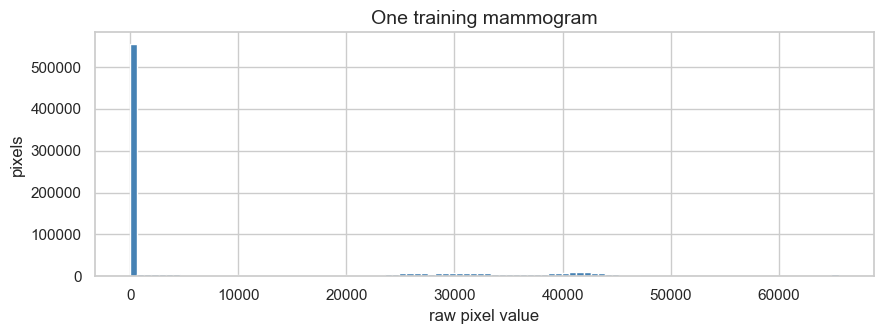

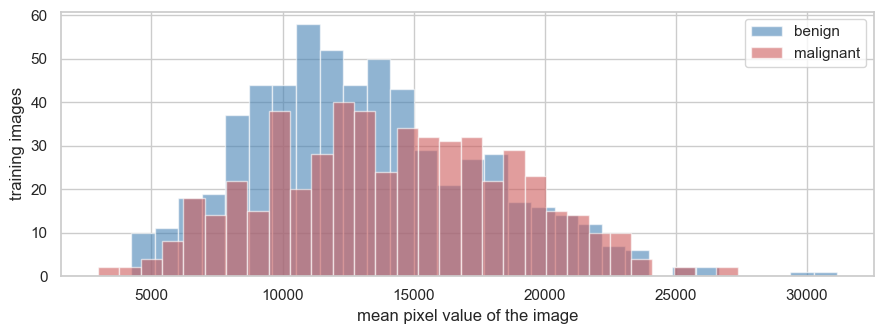

Mean brightness as a classifier, training images: AUC 0.573


In [29]:
def pixel_stats(image_id: str) -> dict:
    arr = pydicom.dcmread(full_lookup[image_id]).pixel_array.astype(np.float32)
    p1, p99 = np.percentile(arr, [1, 99])
    return {
        "image_id": image_id,
        "mean": float(arr.mean()),
        "std": float(arr.std()),
        "min": float(arr.min()),
        "max": float(arr.max()),
        "p1": float(p1),
        "p99": float(p99),
        "n_px": int(arr.size),
    }


labelled = pd.concat([train_df.assign(partition="Train"), val_df.assign(partition="Val")])
labelled = labelled[["image_id", "label", "partition"]]
with ThreadPoolExecutor(max_workers=8) as pool:
    stats = pd.DataFrame(pool.map(pixel_stats, labelled["image_id"]))
intensity = labelled.merge(stats, on="image_id")
print(f"Images decoded: {len(intensity):,}")

one = pydicom.dcmread(full_lookup[train_df["image_id"].iloc[0]]).pixel_array[::4, ::4]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(one.ravel(), bins=100, color="steelblue")
ax.set_xlabel("raw pixel value")
ax.set_ylabel("pixels")
ax.set_title("One training mammogram")
fig.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "intensity_one_image.png")
plt.show()

train_intensity = intensity[intensity["partition"] == "Train"]
fig, ax = plt.subplots(figsize=(9, 3.5))
for label, colour, name in ((0, "steelblue", "benign"), (1, "indianred", "malignant")):
    means = train_intensity.loc[train_intensity["label"] == label, "mean"]
    ax.hist(means, bins=30, alpha=0.6, color=colour, label=name)
ax.set_xlabel("mean pixel value of the image")
ax.set_ylabel("training images")
ax.legend()
fig.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "intensity_by_class.png")
plt.show()

brightness_auc = roc_auc_score(train_intensity["label"], train_intensity["mean"])
print(f"Mean brightness as a classifier, training images: AUC {brightness_auc:.3f}")

### 13.2 What the images need before a network sees them

The files are 16-bit, but most films do not use the whole 16-bit range, and how much of it an image uses varies from one film to the next. The figure shows this: for every training image, the 1st and 99th percentile of its pixel values as a fraction of 65,535.

The project's input paths scale intensity in two ways.

- **A fixed divisor.** The whole-image classifier divides by 65,535. Every image is treated alike, and differences in overall brightness between images are kept.
- **Percentile windowing.** The crop classifiers and the localiser stretch each input between a low and a high percentile of its own values, so that each one uses the full range whatever film it came from. The spread in the figure is the reason.

The pretrained backbones then receive the single channel copied to three, standardised with the ImageNet constants held in `config.NORM_STATS`.

The printed line gives the mean and standard deviation of all training pixels on the 0 to 1 scale, pooled exactly from the per-image statistics. Statistics of this kind come from the training partition alone [3].

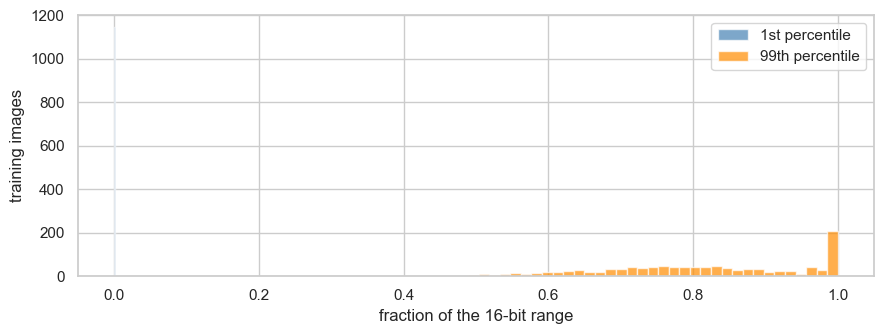

Training pixels, 0 to 1 scale: mean 0.2116, standard deviation 0.2657
99th percentile per training image: median 0.812, 0.416 to 1.000


In [30]:
def pooled(df: pd.DataFrame) -> tuple[float, float]:
    n = df["n_px"].sum()
    mean = (df["mean"] * df["n_px"]).sum() / n
    variance = (df["n_px"] * (df["std"] ** 2 + (df["mean"] - mean) ** 2)).sum() / n
    return mean / 65535, np.sqrt(variance) / 65535


fig, ax = plt.subplots(figsize=(9, 3.5))
p1, p99 = train_intensity["p1"] / 65535, train_intensity["p99"] / 65535
ax.hist(p1, bins=40, alpha=0.7, color="steelblue", label="1st percentile")
ax.hist(p99, bins=40, alpha=0.7, color="darkorange", label="99th percentile")
ax.set_xlabel("fraction of the 16-bit range")
ax.set_ylabel("training images")
ax.legend()
fig.tight_layout()
fig.savefig(CONFIG["figures_dir"] / "intensity_percentiles.png")
plt.show()

train_mean, train_std = pooled(train_intensity)
print(f"Training pixels, 0 to 1 scale: mean {train_mean:.4f}, standard deviation {train_std:.4f}")
low, high = p99.min(), p99.max()
print(f"99th percentile per training image: median {p99.median():.3f}, {low:.3f} to {high:.3f}")

### 13.3 Training against validation

A difference in brightness between the partitions would be a covariate shift: the models would be validated on images that look different from those they trained on. The table gives the pooled mean and standard deviation of each partition and the median of the per-image means. The last column puts the gap in context by expressing the difference in median against the spread of per-image means within the training partition.

In [31]:
rows = []
for name, df in intensity.groupby("partition"):
    mean, std = pooled(df)
    rows.append(
        {
            "partition": name,
            "images": len(df),
            "pooled mean": mean,
            "pooled std": std,
            "median image mean": df["mean"].median() / 65535,
        }
    )
intensity_shift = pd.DataFrame(rows).set_index("partition")
spread = train_intensity["mean"].std() / 65535
gap = intensity_shift["median image mean"] - intensity_shift.loc["Train", "median image mean"]
intensity_shift["gap to training, in training spreads"] = gap / spread
display(intensity_shift.round(4))

,images,pooled mean,pooled std,median image mean,"gap to training, in training spreads"
partition,,,,,
Train,1146,0.2116,0.2657,0.2016,0.0000
Val,225,0.2060,0.2594,0.1961,-0.0801


## 14. Summary

The table is built from the values computed above, so it cannot disagree with them. Its class weights are those of the whole-image models, computed on the training images; the models trained on lesions compute theirs on the training lesions. The test figures in it are counts: from the pipeline's record, from the length of the pair file, and in the prevalence held in `config`.

In [32]:
def joined(values, spec: str = "") -> str:
    return " / ".join(format(value, spec) for value in values)


val_base = stored["val"]
low, high = val_base["auc_roc_ci"]
scales = inputs[SCALE_COL]
sizes = image_meta[["rows", "cols"]].median()
v = associations["Cramér's V"]
v_density = density_association["Cramér's V"].iloc[0]
v_scanner = scanner_association["Cramér's V"].iloc[0]
malignant_shares = label_balance["malignant share"]
pixel_stats_01 = (train_mean, train_std)
majority = label_balance.loc["Val", "majority-class accuracy"]
prevalences = [config.PREVALENCE[k] for k in ("cbis_test", "nhs_assessment", "nhs_screening")]
mixed_counts = [int(df["labels_mixed"].sum()) for df in PARTITIONS.values()]
zero_counts = [int((df["assessment"] == 0).sum()) for df in PARTITIONS.values()]

summary = {
    "Images described by the case files": f"{len(described):,}",
    "Abnormality rows in the case files": f"{len(raw):,}",
    "Images with more than one mass": str(int((n_masses > 1).sum())),
    "Images whose masses disagree in label, train / validation": joined(mixed_counts),
    "Patients, train / validation / test": joined((recorded[p]["patients"] for p in PARTS), ","),
    "Images, train / validation / test": joined((recorded[p]["images"] for p in PARTS), ","),
    "Patients in more than one partition": str(n_overlap),
    "Malignant share of images, train / validation": joined(malignant_shares, ".3f"),
    "Majority-class accuracy, validation": format(majority, ".3f"),
    "Balanced class weights, benign / malignant": joined(class_weights.values(), ".3f"),
    "Malignancy rate: this dataset / assessment clinic / screening": joined(prevalences, ".4f"),
    "Lesions with exactly one mask and one patch": f"{len(by_lesion):,} of {len(raw):,}",
    "Masks on the same grid as their mammogram": f"{int(same.sum()):,} of {len(grid):,}",
    "Photometric interpretation of the mammograms": joined(image_meta["photometric"].unique()),
    "Bits stored in the mammograms": joined(image_meta["bits_stored"].unique()),
    "Median mammogram size, height x width": f"{sizes['rows']:.0f} x {sizes['cols']:.0f}",
    "Scale reduction along each axis: whole-image classifier / localiser": joined(scales, ".1f"),
    "Cramér's V with the label: shape / margins / assessment / subtlety": joined(v, ".3f"),
    "Cramér's V with the label: density / scanner proxy": joined((v_density, v_scanner), ".3f"),
    "Images at assessment 0, train / validation": joined(zero_counts),
    "Specialist baseline on validation, AUC [95 % interval]": (
        f"{val_base['auc_roc']:.3f} [{low:.3f}, {high:.3f}] on {val_base['n']} images"
    ),
    "Breasts with both views, train / validation": joined(view_coverage["share with both"], ".3f"),
    "Lesion pairs, train / validation / test": joined(pair_table["pairs"].astype(int)),
    "Training pixels, 0 to 1 scale: mean / standard deviation": joined(pixel_stats_01, ".4f"),
    "Mean brightness as a classifier, training AUC": format(brightness_auc, ".3f"),
}

table = "\n".join(f"| {name} | {value} |" for name, value in summary.items())
display(Markdown("| property | value |\n| :--- | :--- |\n" + table))

| property | value |
| :--- | :--- |
| Images described by the case files | 1,592 |
| Abnormality rows in the case files | 1,696 |
| Images with more than one mass | 71 |
| Images whose masses disagree in label, train / validation | 4 / 0 |
| Patients, train / validation / test | 644 / 129 / 119 |
| Images, train / validation / test | 1,146 / 225 / 221 |
| Patients in more than one partition | 0 |
| Malignant share of images, train / validation | 0.465 / 0.480 |
| Majority-class accuracy, validation | 0.520 |
| Balanced class weights, benign / malignant | 0.935 / 1.075 |
| Malignancy rate: this dataset / assessment clinic / screening | 0.4796 / 0.2626 / 0.0090 |
| Lesions with exactly one mask and one patch | 1,696 of 1,696 |
| Masks on the same grid as their mammogram | 1,618 of 1,696 |
| Photometric interpretation of the mammograms | MONOCHROME2 |
| Bits stored in the mammograms | 16 |
| Median mammogram size, height x width | 5281 x 3000 |
| Scale reduction along each axis: whole-image classifier / localiser | 23.6 / 5.4 |
| Cramér's V with the label: shape / margins / assessment / subtlety | 0.514 / 0.609 / 0.630 / 0.204 |
| Cramér's V with the label: density / scanner proxy | 0.071 / 0.023 |
| Images at assessment 0, train / validation | 128 / 16 |
| Specialist baseline on validation, AUC [95 % interval] | 0.863 [0.810, 0.909] on 209 images |
| Breasts with both views, train / validation | 0.705 / 0.705 |
| Lesion pairs, train / validation / test | 491 / 100 / 101 |
| Training pixels, 0 to 1 scale: mean / standard deviation | 0.2116 / 0.2657 |
| Mean brightness as a classifier, training AUC | 0.573 |

### What follows for the design

1. **Partition by patient, once, into three.** Choices are made on validation data, and no test result is the criterion for any selection (sections 1 and 4).
2. **Work on lesions.** An image can hold several masses with different labels, so the image-level label is ambiguous where the lesion-level one is not (section 2.3).
3. **Choose the mask by content.** The case files' mask column names the right directory, but for most lesions that directory also holds the patch, and the file names it gives are not the names on disk in the copy of the dataset used here. File area identifies the mask for every lesion and agrees with bit depth (section 3).
4. **Measure with the area under the ROC curve.** Report sensitivity and specificity at a threshold fitted on validation data, and predictive values only after re-weighting to a stated prevalence. The classes are close to balanced, so the balanced class weights are close to one (section 5).
5. **Compare with the specialists on the same images.** The baseline is the BI-RADS assessment with category 0 left out, and every model is compared with it on the images that have a category (section 8).
6. **Treat two-view results as subset results.** Only part of the lesions form a CC and MLO pair (section 9).
7. **One decoding path.** Every mammogram has the same bit depth and photometric interpretation, so a fixed divisor is valid wherever absolute brightness is to be kept (section 11).
8. **Find the mass before classifying it.** At the whole-image classifier's input size a mass keeps little of its margin, and the margin is the visible feature most strongly associated with the label (sections 6 and 12). This is the case for a localisation stage; `02_lesion_geometry` sizes it.
9. **Window crops by percentile.** The films use different parts of the 16-bit range, so a fixed divisor shows the same tissue at a different brightness from film to film (section 13.2). Overall brightness also has a weak association with the label (section 13.1).

### Limits of the data

- The images are digitised screen-film mammograms, not digital mammography [1].
- Mass cases only, and every image has a mass that a radiologist marked: the benign class is benign masses, not normal breasts.
- The dataset is small by the standards of the published systems it is compared with [8].
- The films come from more than one scanner. Scanner type is not associated with the label here (section 12.2), but it remains a source of variation.
- The specialists' assessment was made with more information than the models receive.

### Workflow steps covered

The problem and the data (step 1), the measure of success (step 2) and the evaluation protocol (step 3) of the workflow [3]. Model development starts from here.